Nama: Rahman Nendhiarto

Nim: (2200018315)

Slot: selasa 15.15

POLA PERTEMUAN 10


In [ ]:
# Install library bioinformatika
!pip install biopython scikit-learn

from Bio import SeqIO
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:

# 1. Download FASTA Human Genome dari FTP NCBI GenBank
# Download contoh file FASTA (misalnya: Escherichia coli)
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz

# Ekstrak file gzip
!gunzip GCF_000005845.2_ASM584v2_genomic.fna.gz





--2025-07-01 09:10:30--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 130.14.250.12, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1379902 (1.3M) [application/x-gzip]
Saving to: ‘GCF_000005845.2_ASM584v2_genomic.fna.gz’

GCF_000005845.2_ASM 100%[===================>]   1.32M  --.-KB/s    in 0.1s    

2025-07-01 09:10:30 (13.0 MB/s) - ‘GCF_000005845.2_ASM584v2_genomic.fna.gz’ saved [1379902/1379902]

gzip: GCF_000005845.2_ASM584v2_genomic.fna already exists; do you wish to overwrite (y or n)? y


In [ ]:
# 2. Baca dan Parse dengan Biopython

# Path ke FASTA yang telah diekstrak
fasta_path = "GCF_000005845.2_ASM584v2_genomic.fna"
FRAG_LEN = 200
seq_fragments = []
for  rec in SeqIO.parse(fasta_path, "fasta"):
     seq = str(rec.seq).upper().replace("N","")
    # potong menjadi windows non-overlap
     for i in range(0, len(seq) - FRAG_LEN + 1, FRAG_LEN):
        seq_fragments.append(seq[i:i+FRAG_LEN])

In [ ]:
# 3. Hitung Frekuensi A/C/G/T per Chromosome
def extract_features(seqs, k=3):
    all_feats = []
    for seq in seqs:
        cnt = Counter(seq)
        total = len(seq)
        # frekuensi A/C/G/T + GC
        feats = {
            "A_freq": cnt["A"]/total,
            "C_freq": cnt["C"]/total,
            "G_freq": cnt["G"]/total,
            "T_freq": cnt["T"]/total,
            "GC_content": (cnt["G"]+cnt["C"])/total,
        }
        # frekuensi k-mer
        total_k = total - k + 1
        kmers = [seq[i:i+k] for i in range(total_k)]
        kcnt = Counter(kmers)
        for kmer, c in kcnt.items():
            feats[f"kmer_{kmer}"] = c/total_k
        all_feats.append(feats)
    # DataFrame, missing k-mer akan diisi 0
    return pd.DataFrame(all_feats).fillna(0)

In [ ]:
# 4. Labeling dummy: fragmen pertama 50% = promotor (1), sisanya non (0)
n = len(seq_fragments)
labels = np.array([1]* (n//2) + [0]* (n - n//2))

# 5. Bangun fitur & split data
df = extract_features(seq_fragments, k=3)
X = df.values
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 6. Latih model & evaluasi
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.55      0.54      0.55      3482
           1       0.55      0.56      0.56      3481

    accuracy                           0.55      6963
   macro avg       0.55      0.55      0.55      6963
weighted avg       0.55      0.55      0.55      6963



In [ ]:
# membaca dan print 5 record pertama (header + 2 baris sekuens)
def show_fasta_snippet(path, records=5, seq_lines=2):
    with open(path) as f:
        rec_count = 0
        for line in f:
            if line.startswith(">"):
                rec_count += 1
                print(line.strip())
                # print beberapa baris sekuens berikutnya
                for _ in range(seq_lines):
                    print(next(f).strip())
                print()
                if rec_count >= records:
                    break

# memanggil fungsi
show_fasta_snippet("GCF_000005845.2_ASM584v2_genomic.fna", records=4, seq_lines=1)


>NC_000913.3 Escherichia coli str. K-12 substr. MG1655, complete genome
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCTTCTGAACTG



In [ ]:
pd.set_option('display.max_columns', None)
print(df.head())

   A_freq  C_freq  G_freq  T_freq  GC_content  kmer_AGC  kmer_GCT  kmer_CTT  \
0   0.350   0.185   0.185   0.280       0.370  0.020202  0.010101  0.020202   
1   0.280   0.265   0.250   0.205       0.515  0.010101  0.010101  0.005051   
2   0.225   0.315   0.265   0.195       0.580  0.020202  0.010101  0.010101   
3   0.255   0.230   0.260   0.255       0.490  0.010101  0.015152  0.005051   
4   0.180   0.275   0.305   0.240       0.580  0.005051  0.035354  0.005051   

   kmer_TTT  kmer_TTC  kmer_TCA  kmer_CAT  kmer_ATT  kmer_TCT  kmer_CTG  \
0  0.025253  0.015152  0.010101  0.025253  0.030303  0.025253  0.035354   
1  0.045455  0.015152  0.010101  0.025253  0.010101  0.005051  0.015152   
2  0.030303  0.010101  0.010101  0.005051  0.020202  0.015152  0.020202   
3  0.020202  0.005051  0.015152  0.025253  0.030303  0.000000  0.025253   
4  0.010101  0.015152  0.010101  0.015152  0.025253  0.010101  0.045455   

   kmer_TGA  kmer_GAC  kmer_ACT  kmer_TGC  kmer_GCA  kmer_CAA  kmer_AAC  \

# **POSTEST**

# Sebelum Di Ubah

  tetramer  count     freq
0     GGCG   1024  0.01024
1     GCTG    948  0.00948
2     CTGG    850  0.00850
3     TGGC    843  0.00843
4     GCGC    798  0.00798


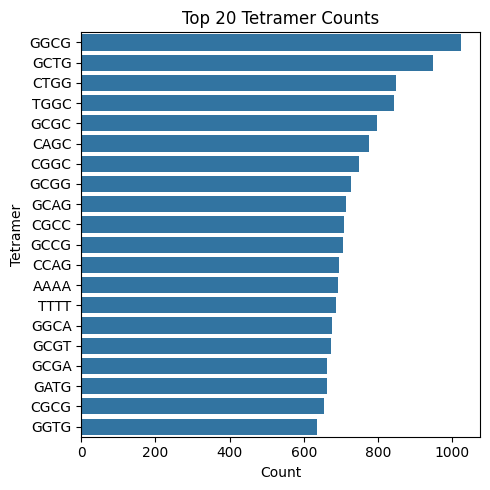

In [ ]:
#6. membuat Tetramer, count dan freaq
import itertools
import seaborn as sns
seq = ""
with open(fasta_path) as f:
    for line in f:
        if line.startswith(">"):
            continue
        seq += line.strip()
        if len(seq) >= 100000:
            break
ncov_dna = seq.upper().replace("N", "")


tetramers = [''.join(p) for p in itertools.product("ACGT", repeat=4)]


from collections import Counter
comp = Counter(ncov_dna[i:i+4] for i in range(len(ncov_dna)-4))

composition = {t: comp.get(t, 0) for t in tetramers}
total = sum(composition.values())
norm_freq = {t: composition[t]/total for t in tetramers}


df = pd.DataFrame({
    'tetramer': list(composition.keys()),
    'count': list(composition.values()),
    'freq': list(norm_freq.values())
})
df_sorted = df.sort_values(by='count', ascending=False).reset_index(drop=True)


print(df_sorted.head(5))
plt.figure(figsize=(5,5))
sns.barplot(data=df_sorted.head(20), x='count', y='tetramer')
plt.title('Top 20 Tetramer Counts')
plt.xlabel('Count')
plt.ylabel('Tetramer')
plt.tight_layout()
plt.show()

# Setelah di Ubah

  hexamer  count     freq
0  CTGGCG    153  0.00153
1  GCTGGC    145  0.00145
2  CGCTGG    127  0.00127
3  GCGCTG    119  0.00119
4  GGCGAT    116  0.00116


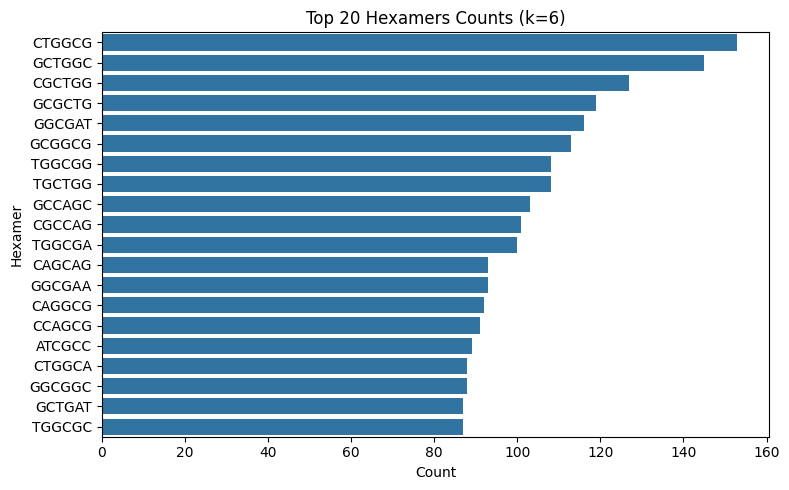

In [ ]:
#6. membuat Heksamer, count dan freaq (mengubah dari Tetramer menjadi Heksamer)
import itertools
import seaborn as sns
seq = ""
with open(fasta_path) as f:
    for line in f:
        if line.startswith(">"):
            continue
        seq += line.strip()
        if len(seq) >= 100000: # Batasi ukuran sekuens untuk komputasi yang lebih cepat
            break
ncov_dna = seq.upper().replace("N", "")

# Mengubah dari tetramer (k=4) menjadi heksamer (k=6)
k = 6
hexamers = [''.join(p) for p in itertools.product("ACGT", repeat=k)]

from collections import Counter
# Menghitung frekuensi heksamer
comp = Counter(ncov_dna[i:i+k] for i in range(len(ncov_dna)-k+1))

# Mengubah dari tetramer (k=4) menjadi heksamer (k=6)
composition = {t: comp.get(t, 0) for t in hexamers}
total = sum(composition.values())
norm_freq = {t: composition[t]/total for t in hexamers}


df = pd.DataFrame({
    'hexamer': list(composition.keys()), # Mengganti nama kolom menjadi 'hexamer'
    'count': list(composition.values()),
    'freq': list(norm_freq.values())
})
df_sorted = df.sort_values(by='count', ascending=False).reset_index(drop=True)


print(df_sorted.head(5))
plt.figure(figsize=(8,5)) # Menyesuaikan ukuran plot
sns.barplot(data=df_sorted.head(20), x='count', y='hexamer') # Mengganti y menjadi 'hexamer'
plt.title(f'Top 20 Hexamers Counts (k={k})') # Mengubah judul plot
plt.xlabel('Count')
plt.ylabel('Hexamer') # Mengubah label y
plt.tight_layout()
plt.show()

# Penjelasan Postest

# **Perubahan utama pada kode adalah:**

Sebelum Diubah: Kode mencari dan menghitung pola 4 huruf (disebut tetramer)
dalam DNA.

Setelah Diubah: Kode mencari dan menghitung pola 6 huruf (disebut heksamer) dalam DNA.

Perbedaannya,

Hasilnya menunjukkan:

Sebelum diubah, Saya melihat pola 4 huruf yang paling sering muncul.

Setelah diubah, saya melihat pola 6 huruf yang paling sering muncul.

Karena pola 6 huruf lebih panjang, ada lebih banyak kemungkinan pola (4096 heksamer vs 256 tetramer), dan masing-masing pola 6 huruf cenderung muncul lebih jarang dibandingkan pola 4 huruf.

Saya mengubah analisis dari tetramer (pola 4 huruf) menjadi heksamer (pola 6 huruf) dalam sekuens DNA. Perubahan ini signifikan karena heksamer (4096 kemungkinan) lebih spesifik dan dapat mengidentifikasi pola biologis yang lebih bermakna dibandingkan tetramer (256 kemungkinan). Hasilnya melihat pola 6-huruf yang paling sering muncul, yang berpotensi merepresentasikan sinyal fungsional yang lebih spesifik dalam genom, meskipun heksamer cenderung muncul lebih jarang dibandingkan tetramer dan memerlukan data sekuens yang lebih banyak untuk analisis frekuensi yang komprehensif.

Jadi, intinya, kode diubah untuk melihat pola DNA yang lebih panjang.